# TPC drift-velocity postprocess plots — separate canvases, larger labels

This updated notebook:

- reads the already-saved ROOT `TGraph` / histogram objects directly
- uses **one plot per canvas**
- increases margins:
  - left = `0.14`
  - bottom = `0.14`
  - right = `0.05`
  - top = `0.06`
- increases axis label size to **0.05**
- increases axis title size to **0.06**

Each plot cell has its own `YLIM` and `XLIM` at the top, so you can tweak every plot independently.

In [1]:
import os
import ROOT as root

root.gStyle.SetOptStat(0)
root.gStyle.SetPadGridX(True)
root.gStyle.SetPadGridY(True)

DATA_DIR = "input/"
OUTDIR = "dv_plots"
os.makedirs(OUTDIR, exist_ok=True)

fP = root.TFile.Open(os.path.join(DATA_DIR, "tpc_dv_postprocess_P.root"))
fT = root.TFile.Open(os.path.join(DATA_DIR, "tpc_dv_postprocess_T.root"))
fL = root.TFile.Open(os.path.join(DATA_DIR, "tpc_dv_postprocess_Long_Tony1.root"))

for label, f in [("P", fP), ("T", fT), ("LONG", fL)]:
    if not f or f.IsZombie():
        raise OSError(f"Could not open {label} file")
    print("Opened", label, f.GetName())

Welcome to JupyROOT 6.30/06
Opened P input/tpc_dv_postprocess_P.root
Opened T input/tpc_dv_postprocess_T.root
Opened LONG input/tpc_dv_postprocess_Long_Tony1.root


In [2]:
# Optional: inspect stored objects
for label, f in [("P", fP), ("T", fT), ("LONG", fL)]:
    print(f"\n===== {label} =====")
    for k in f.GetListOfKeys():
        print(f"{k.GetName():35s} {k.GetClassName()}")


===== P =====
g_mean_south                        TGraph
g_mean_north                        TGraph
g_mean_combined                     TGraph
g_cdb                               TGraph
g_cdb_t0corr                        TGraph
g_ratio_south                       TGraph
g_ratio_north                       TGraph
g_ratio_combined                    TGraph
g_ratio_corr_south                  TGraph
g_ratio_corr_north                  TGraph
g_ratio_corr_combined               TGraph
g_cdb_t0_ns                         TGraph
g_phg_t0_ns                         TGraph
g_delta_t0_ns                       TGraph
g_t0_correction_factor              TGraph
g_diff_south                        TGraph
g_diff_north                        TGraph
g_diff_combined                     TGraph
g_cmfield                           TGraph
g_pressure                          TGraph
g_temperatureK                      TGraph
g_avg_ratio_r_south                 TGraphErrors
g_avg_ratio_r_north              

In [3]:
# Helpers

def get_obj(f, name, clone_name):
    obj = f.Get(name)
    if not obj:
        raise KeyError(f"{name} not found in {f.GetName()}")
    out = obj.Clone(clone_name)
    if hasattr(out, "SetDirectory"):
        out.SetDirectory(0)
    return out

def make_canvas(name, title="", w=950, h=700):
    c = root.TCanvas(name, title, w, h)
    c.SetLeftMargin(0.14)
    c.SetBottomMargin(0.14)
    c.SetRightMargin(0.05)
    c.SetTopMargin(0.06)
    c.SetGridx(True)
    c.SetGridy(True)
    return c

def style_graph(g, color=root.kBlack, marker=20):
    if hasattr(g, "SetLineColor"):
        g.SetLineColor(color)
        g.SetLineWidth(0)
    if hasattr(g, "SetMarkerColor"):
        g.SetMarkerColor(color)
        g.SetMarkerStyle(marker)
        if (marker <22): g.SetMarkerSize(1.5)
        else: g.SetMarkerSize(2.0)

def style_axes(obj):
    x = obj.GetXaxis()
    y = obj.GetYaxis()
    x.SetLabelSize(0.05)
    y.SetLabelSize(0.05)
    x.SetTitleSize(0.06)
    y.SetTitleSize(0.06)
    x.SetTitleOffset(1.0)
    y.SetTitleOffset(1.05)

def apply_limits(obj, ylim=None, xlim=None):
    if ylim is not None:
        if hasattr(obj, "SetMinimum"):
            obj.SetMinimum(ylim[0])
        if hasattr(obj, "SetMaximum"):
            obj.SetMaximum(ylim[1])
        try:
            obj.GetYaxis().SetRangeUser(*ylim)
        except Exception:
            pass
    if xlim is not None:
        try:
            obj.GetXaxis().SetLimits(*xlim)
        except Exception:
            try:
                obj.GetXaxis().SetRangeUser(*xlim)
            except Exception:
                pass

def draw_one(g, title, ylim=None, xlim=None, option="APL"):
    g.SetTitle(title)
    style_axes(g)
    apply_limits(g, ylim, xlim)
    g.Draw(option)
    root.gPad.Update()
    style_axes(g)
    apply_limits(g, ylim, xlim)
    root.gPad.Modified()
    root.gPad.Update()

def draw_overlay(items, title, ylim=None, xlim=None, leg_xy=(0.16, 0.75, 0.52, 0.90)):
    leg = root.TLegend(*leg_xy)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextSize(0.06)
    first = True
    for g, label, color, marker in items:
        style_graph(g, color, marker)
        if first:
            g.SetTitle(title)
            style_axes(g)
            apply_limits(g, ylim, xlim)
            g.Draw("APL")
            root.gPad.Update()
            style_axes(g)
            apply_limits(g, ylim, xlim)
            first = False
        else:
            g.Draw("PL SAME")
        leg.AddEntry(g, label, "lp")
    leg.Draw()
    root.gPad.Modified()
    root.gPad.Update()
    return leg

def save_canvas(c, stem, save=False):
    if save:
        c.SaveAs(os.path.join(OUTDIR, stem + ".pdf"))
        c.SaveAs(os.path.join(OUTDIR, stem + ".png"))
        print("Saved", stem)

## Basic quantities

In [30]:
# Pure PHGarfield vs CDB
YLIM = (7.21, 7.85)           # example: (7.30, 7.65)
XLIM = None
SAVE = True

g1 = get_obj(fP, "g_mean_combined", "g_pure_cmp")
g2 = get_obj(fP, "g_cdb", "g_cdb_cmp")

c = make_canvas("c_pure_vs_cdb")
leg = draw_overlay(
    [(g1, "Pure PHGarfield", root.kBlue+1, 20),
     (g2, "CDB DV", root.kBlack, 21)],
    "Pure PHGarfield vs CDB;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "00_pure_phgarfield_vs_cdb", SAVE)

Saved 00_pure_phgarfield_vs_cdb


Info in <TCanvas::Print>: pdf file dv_plots/00_pure_phgarfield_vs_cdb.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/00_pure_phgarfield_vs_cdb.png has been created


Saved 01_pure_phgarfield_dv


Info in <TCanvas::Print>: pdf file dv_plots/01_pure_phgarfield_dv.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/01_pure_phgarfield_dv.png has been created


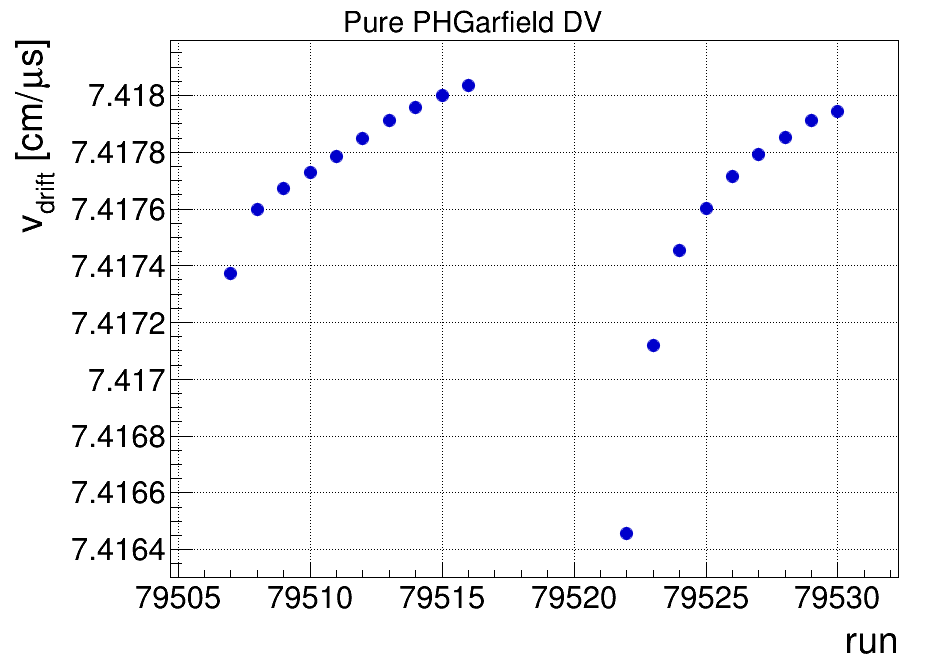

In [4]:
# Pure PHGarfield DV
YLIM = None            # example: (7.4164, 7.4184)
XLIM = None            # example: (79506, 79531)
SAVE = True

g = get_obj(fP, "g_mean_combined", "g_pure_dv")
style_graph(g, root.kBlue+1, 20)

c = make_canvas("c_pure_dv")
c.SetLeftMargin(0.18)
draw_one(g, "Pure PHGarfield DV;run;v_{drift} [cm/#mus]", YLIM, XLIM)

g.GetYaxis().SetTitleOffset(1.5)
c.Draw()
save_canvas(c, "01_pure_phgarfield_dv", SAVE)

Saved 02_cdb_dv


Info in <TCanvas::Print>: pdf file dv_plots/02_cdb_dv.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/02_cdb_dv.png has been created


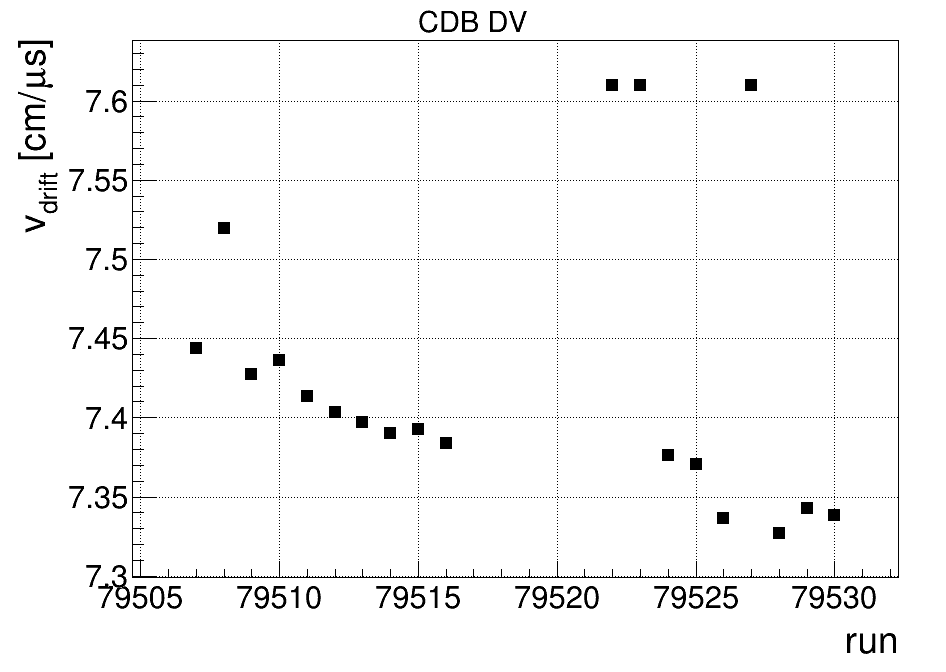

In [5]:
# CDB DV
YLIM = None            # example: (7.30, 7.65)
XLIM = None
SAVE = True

g = get_obj(fP, "g_cdb", "g_cdb_dv")
style_graph(g, root.kBlack, 21)

c = make_canvas("c_cdb_dv")
draw_one(g, "CDB DV;run;v_{drift} [cm/#mus]", YLIM, XLIM)
c.Draw()
save_canvas(c, "02_cdb_dv", SAVE)

Saved 03_cdb_and_phgarfield_t0


Info in <TCanvas::Print>: pdf file dv_plots/03_cdb_and_phgarfield_t0.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/03_cdb_and_phgarfield_t0.png has been created


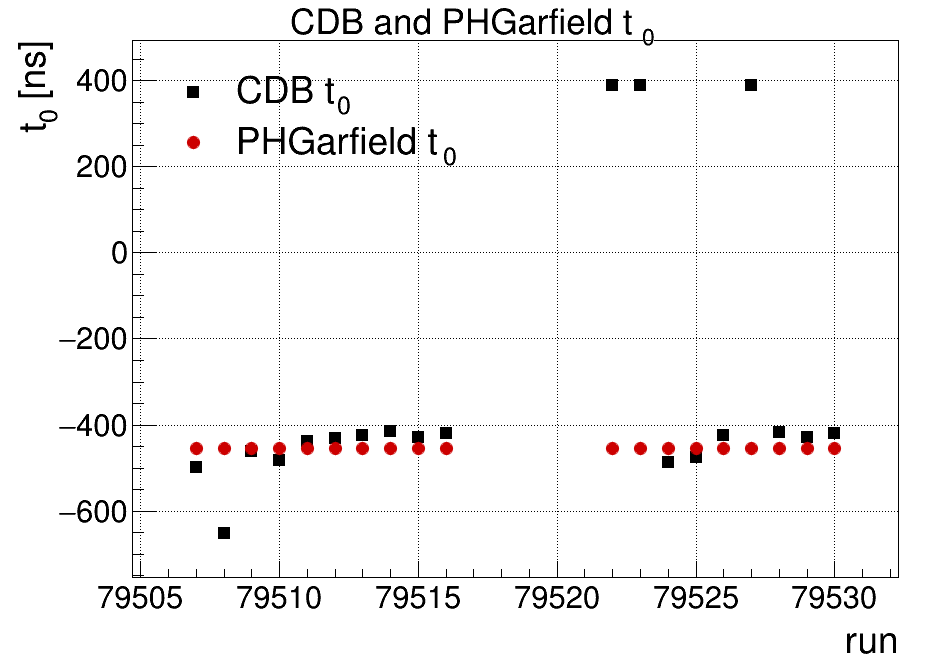

In [6]:
# CDB and PHGarfield t0
YLIM = None            # example: (-700, 500)
XLIM = None
SAVE = True

g1 = get_obj(fP, "g_cdb_t0_ns", "g_cdb_t0")
g2 = get_obj(fP, "g_phg_t0_ns", "g_phg_t0")

c = make_canvas("c_t0_overlay")
leg = draw_overlay(
    [(g1, "CDB t_{0}", root.kBlack, 21),
     (g2, "PHGarfield t_{0}", root.kRed+1, 20)],
    "CDB and PHGarfield t_{0};run;t_{0} [ns]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "03_cdb_and_phgarfield_t0", SAVE)

In [31]:
# PHGarfield t0 - CDB t0
YLIM = (-200, 200)            # example: (-900, 250)
XLIM = None
SAVE = True

g = get_obj(fP, "g_delta_t0_ns", "g_delta_t0")
style_graph(g, root.kMagenta+1, 20)

c = make_canvas("c_delta_t0")
draw_one(g, "PHGarfield t_{0} - CDB t_{0};run;#Delta t_{0} [ns]", YLIM, XLIM)
c.Draw()
save_canvas(c, "04_delta_t0", SAVE)

Saved 04_delta_t0


Info in <TCanvas::Print>: pdf file dv_plots/04_delta_t0.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/04_delta_t0.png has been created


Saved 05_cdb_dv_corrected_to_phgarfield_t0


Info in <TCanvas::Print>: pdf file dv_plots/05_cdb_dv_corrected_to_phgarfield_t0.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/05_cdb_dv_corrected_to_phgarfield_t0.png has been created


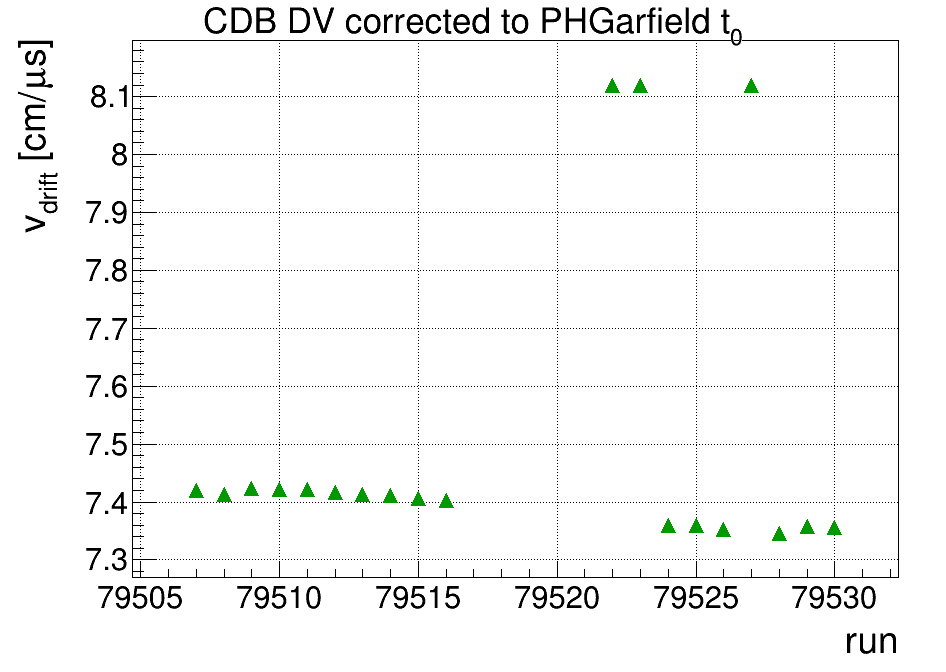

In [8]:
# CDB DV corrected to PHGarfield t0
YLIM = None            # example: (7.30, 8.20)
XLIM = None
SAVE = True

g = get_obj(fP, "g_cdb_t0corr", "g_cdb_t0corr")
style_graph(g, root.kGreen+2, 22)

c = make_canvas("c_cdb_t0corr")
draw_one(g, "CDB DV corrected to PHGarfield t_{0};run;v_{drift} [cm/#mus]", YLIM, XLIM)
c.Draw()
save_canvas(c, "05_cdb_dv_corrected_to_phgarfield_t0", SAVE)

## Comparisons, differences, and ratios

Saved 06_pure_phgarfield_vs_cdb


Info in <TCanvas::Print>: pdf file dv_plots/06_pure_phgarfield_vs_cdb.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/06_pure_phgarfield_vs_cdb.png has been created


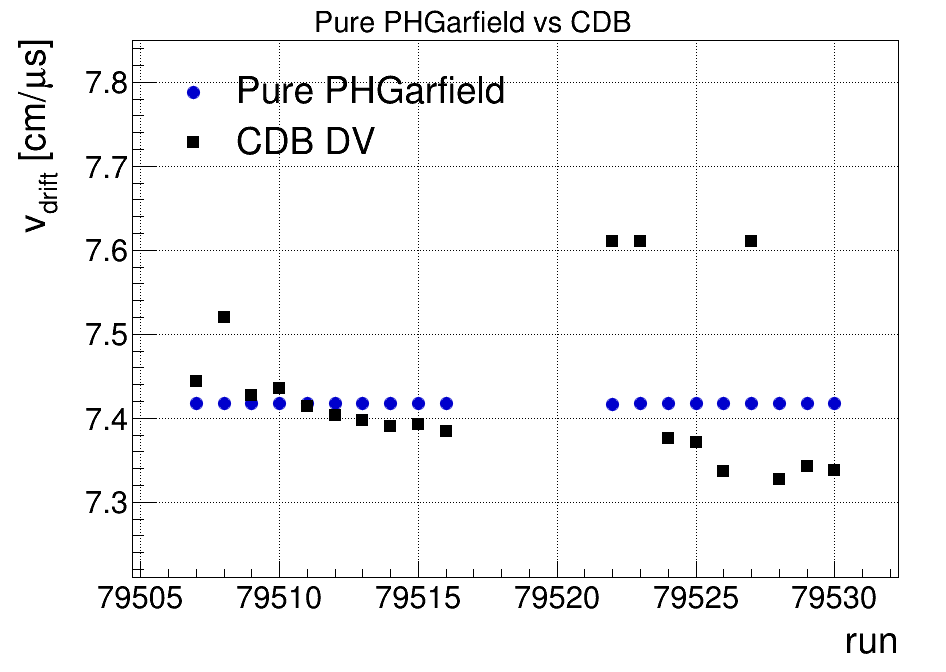

In [9]:
# Pure PHGarfield vs CDB
YLIM = (7.31, 7.55)           # example: (7.30, 7.65)
XLIM = None
SAVE = True

g1 = get_obj(fP, "g_mean_combined", "g_pure_cmp")
g2 = get_obj(fP, "g_cdb", "g_cdb_cmp")

c = make_canvas("c_pure_vs_cdb")
leg = draw_overlay(
    [(g1, "Pure PHGarfield", root.kBlue+1, 20),
     (g2, "CDB DV", root.kBlack, 21)],
    "Pure PHGarfield vs CDB;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "06_pure_phgarfield_vs_cdb", SAVE)

Saved 07_pure_phgarfield_vs_corrected_cdb


Info in <TCanvas::Print>: pdf file dv_plots/07_pure_phgarfield_vs_corrected_cdb.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/07_pure_phgarfield_vs_corrected_cdb.png has been created


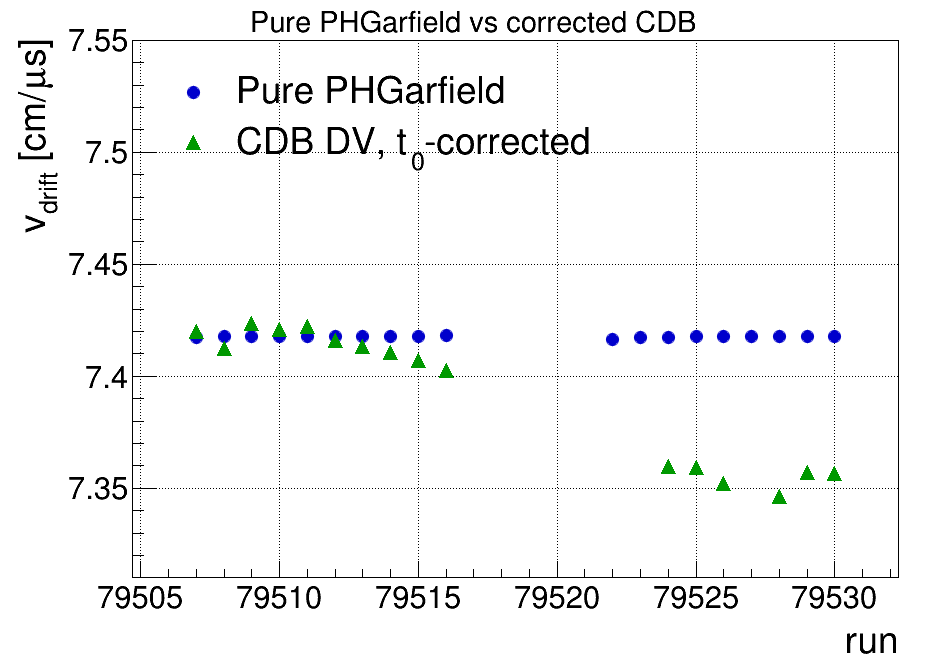

In [10]:
# Pure PHGarfield vs corrected CDB
YLIM = (7.31, 7.55)            # example: (7.30, 8.20)
XLIM = None
SAVE = True

g1 = get_obj(fP, "g_mean_combined", "g_pure_vs_corr")
g2 = get_obj(fP, "g_cdb_t0corr", "g_corr_vs_pure")

c = make_canvas("c_pure_vs_corrcdb")
leg = draw_overlay(
    [(g1, "Pure PHGarfield", root.kBlue+1, 20),
     (g2, "CDB DV, t_{0}-corrected", root.kGreen+2, 22)],
    "Pure PHGarfield vs corrected CDB;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "07_pure_phgarfield_vs_corrected_cdb", SAVE)

Saved 08_ratio_raw


Info in <TCanvas::Print>: pdf file dv_plots/08_ratio_raw.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/08_ratio_raw.png has been created


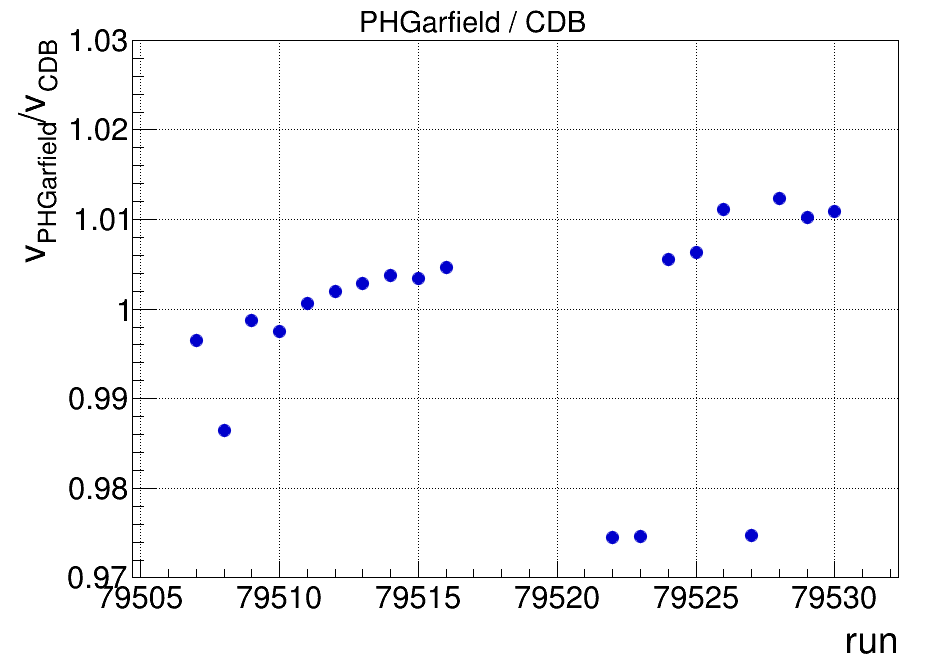

In [11]:
# PHGarfield / CDB ratio
YLIM = (0.97, 1.03)            # example: (0.97, 1.03)
XLIM = None
SAVE = True

g = get_obj(fP, "g_ratio_combined", "g_ratio_raw")
style_graph(g, root.kBlue+1, 20)

c = make_canvas("c_ratio_raw")
draw_one(g, "PHGarfield / CDB", YLIM, XLIM)
c.Draw()
save_canvas(c, "08_ratio_raw", SAVE)

Saved 09_ratio_corrected


Info in <TCanvas::Print>: pdf file dv_plots/09_ratio_corrected.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/09_ratio_corrected.png has been created


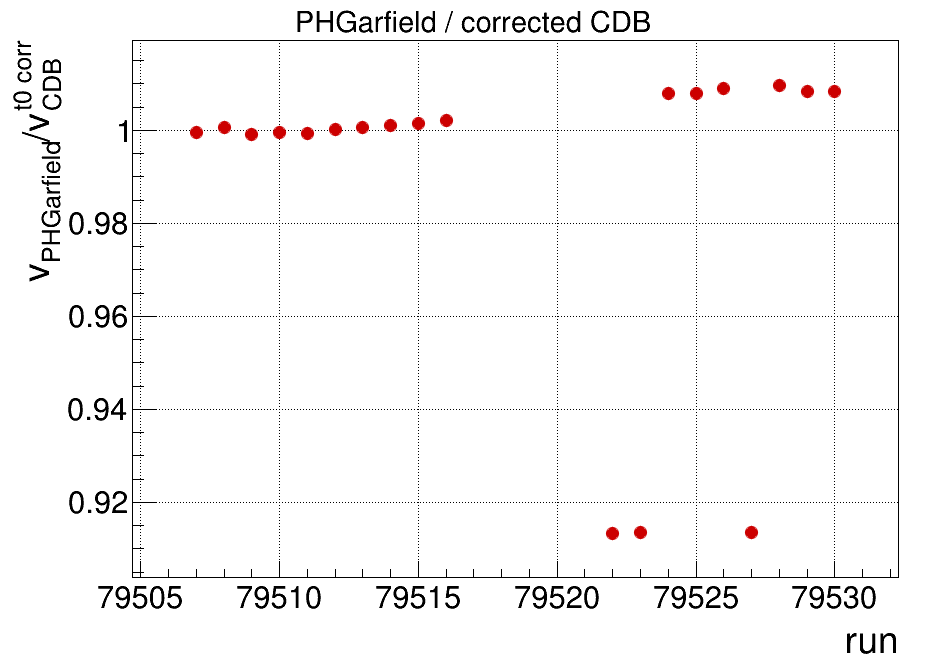

In [12]:
# PHGarfield / corrected CDB ratio
YLIM = None            # example: (0.90, 1.05)
XLIM = None
SAVE = True

g = get_obj(fP, "g_ratio_corr_combined", "g_ratio_corr")
style_graph(g, root.kRed+1, 20)

c = make_canvas("c_ratio_corr")
draw_one(g, "PHGarfield / corrected CDB", YLIM, XLIM)
c.Draw()
save_canvas(c, "09_ratio_corrected", SAVE)

Saved 09_ratio_corrected_zoom


Info in <TCanvas::Print>: pdf file dv_plots/09_ratio_corrected_zoom.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/09_ratio_corrected_zoom.png has been created


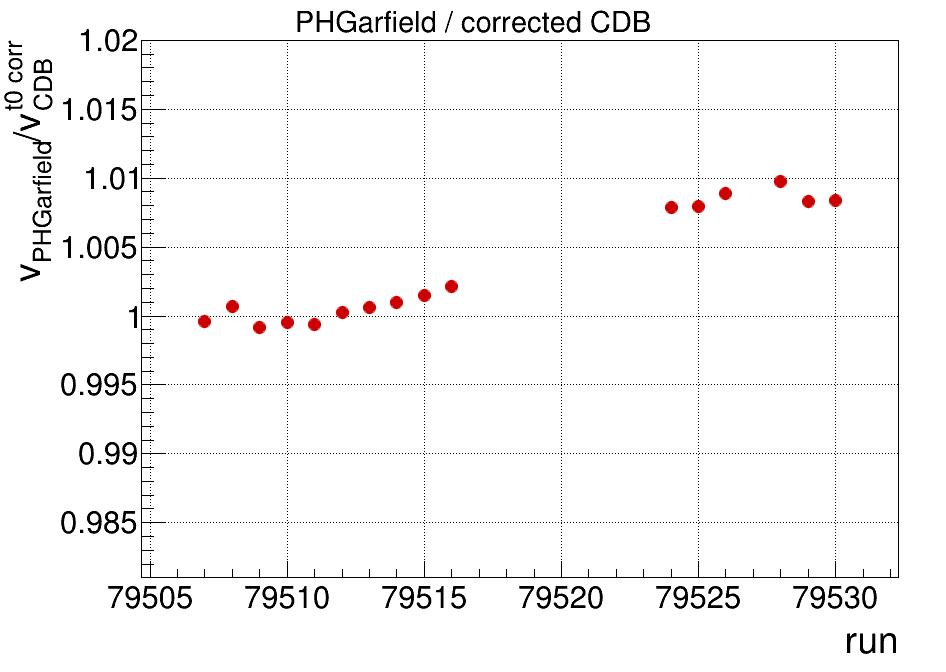

In [13]:
# PHGarfield / corrected CDB ratio
YLIM = (0.981, 1.02)            # example: (0.90, 1.05)
XLIM = None
SAVE = True

g = get_obj(fP, "g_ratio_corr_combined", "g_ratio_corr")
style_graph(g, root.kRed+1, 20)

c = make_canvas("c_ratio_corr_zoom")
draw_one(g, "PHGarfield / corrected CDB", YLIM, XLIM)
c.SetLeftMargin(0.15)
g.GetYaxis().SetTitleOffset(1.25)
c.Draw()
save_canvas(c, "09_ratio_corrected_zoom", SAVE)

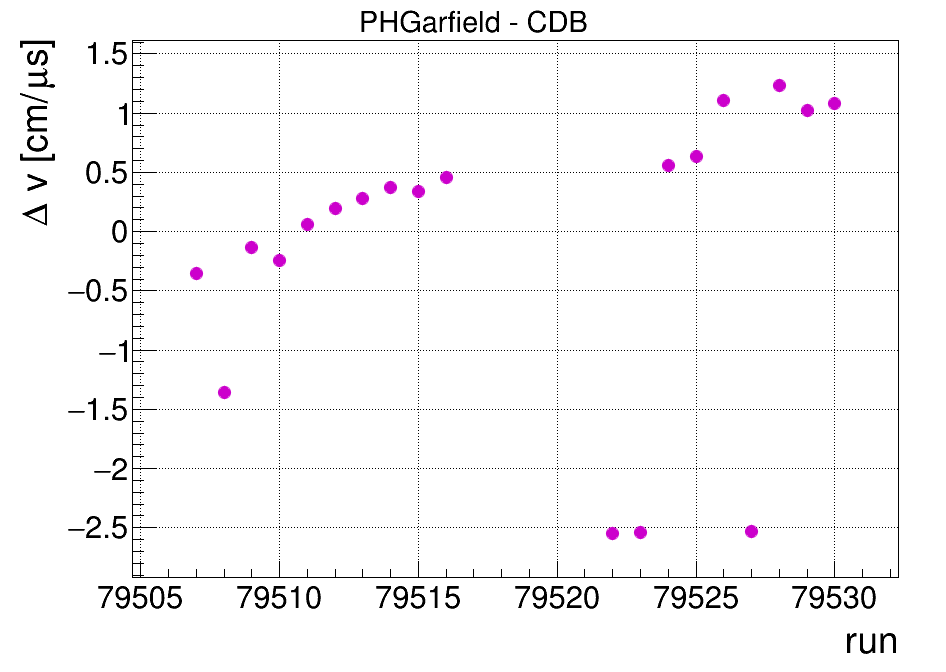

In [14]:
# PHGarfield - CDB difference
YLIM = None            # example: (-0.2, 0.2)
XLIM = None
SAVE = False

g = get_obj(fP, "g_diff_combined", "g_diff")
style_graph(g, root.kMagenta+1, 20)

c = make_canvas("c_diff")
draw_one(g, "PHGarfield - CDB;run;#Delta v [cm/#mus]", YLIM, XLIM)
c.Draw()
save_canvas(c, "10_difference_phgarfield_minus_cdb", SAVE)

## Pressure, temperature, and CM field

In [29]:
# Pressure
YLIM = None
XLIM = None
SAVE = True

g = get_obj(fT, "g_pressure", "g_pressure")
style_graph(g, root.kBlue+1, 20)

c = make_canvas("c_pressure")
draw_one(g, "Pressure;run;pressure [inHg]", YLIM, XLIM)
c.Draw()
save_canvas(c, "11_pressure", SAVE)

Saved 11_pressure


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_pressure
Info in <TCanvas::Print>: pdf file dv_plots/11_pressure.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/11_pressure.png has been created


Saved 12_temperature


Info in <TCanvas::Print>: pdf file dv_plots/12_temperature.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/12_temperature.png has been created


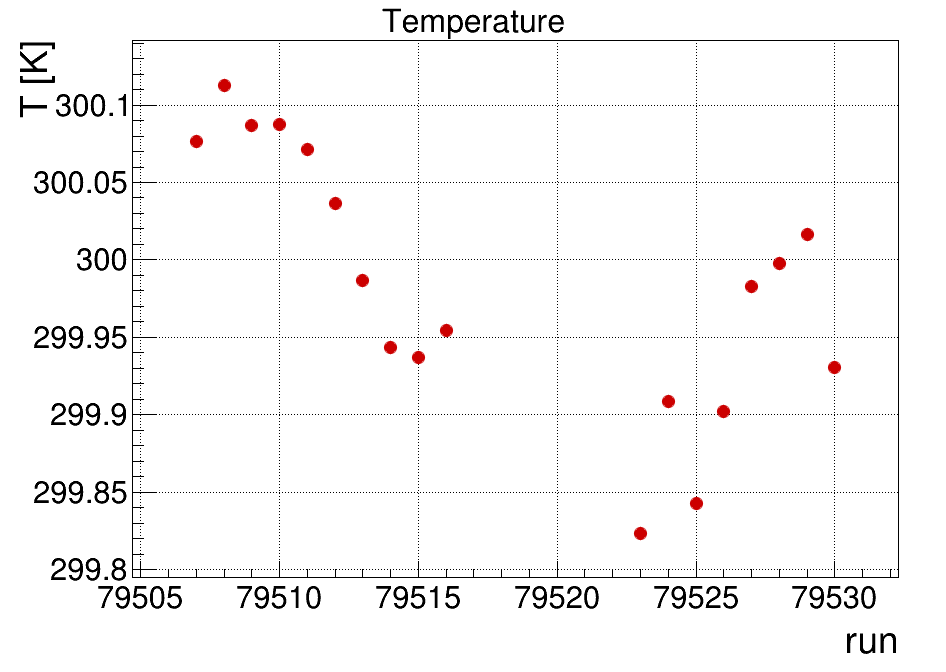

In [16]:
# Temperature
YLIM = None
XLIM = None
SAVE = True

g = get_obj(fT, "g_temperatureK", "g_temperatureK")
style_graph(g, root.kRed+1, 20)

c = make_canvas("c_temperature")
draw_one(g, "Temperature;run;T [K]", YLIM, XLIM)
c.Draw()
save_canvas(c, "12_temperature", SAVE)

Saved 13_cmfield


Info in <TCanvas::Print>: pdf file dv_plots/13_cmfield.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/13_cmfield.png has been created


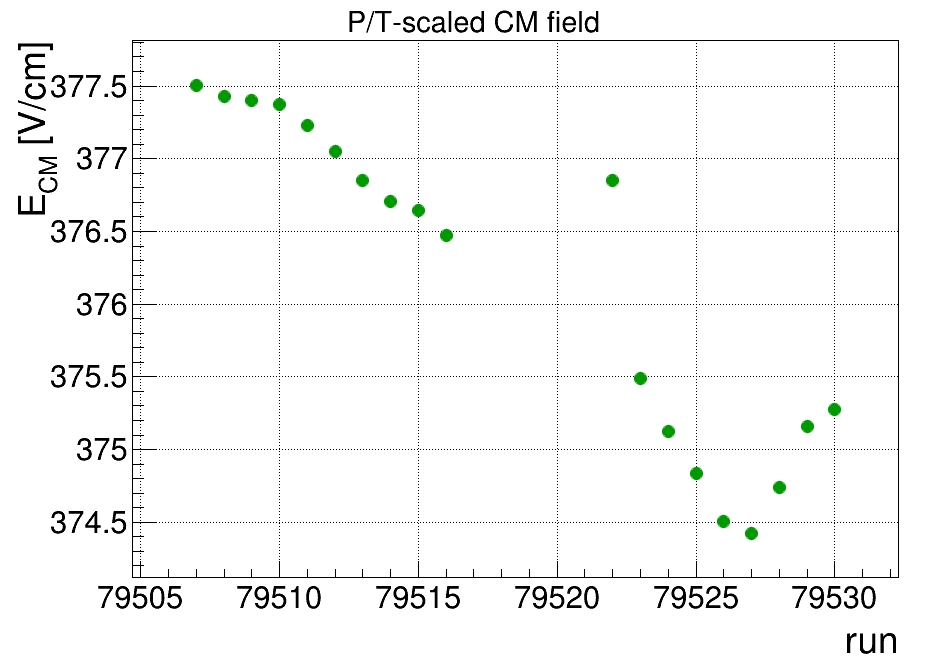

In [17]:
# P/T-scaled CM field
YLIM = None            # example: (360, 390)
XLIM = None
SAVE = True

g = get_obj(fT, "g_cmfield", "g_cmfield")
style_graph(g, root.kGreen+2, 20)

c = make_canvas("c_cmfield")
draw_one(g, "P/T-scaled CM field;run;E_{CM} [V/cm]", YLIM, XLIM)
c.Draw()
save_canvas(c, "13_cmfield", SAVE)

## P/T-corrected PHGarfield vs corrected CDB

Saved 14_new_pt_corrected_phgarfield_vs_corrected_cdb


Info in <TCanvas::Print>: pdf file dv_plots/14_new_pt_corrected_phgarfield_vs_corrected_cdb.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/14_new_pt_corrected_phgarfield_vs_corrected_cdb.png has been created


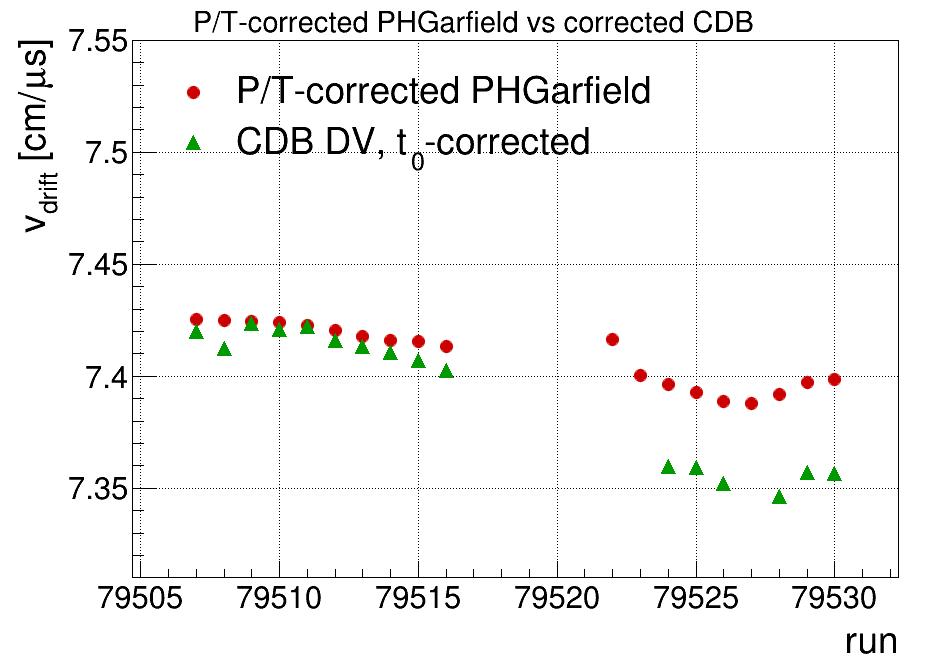

In [18]:
# P/T-corrected PHGarfield vs corrected CDB
YLIM = (7.31, 7.55)            # example: (7.2, 7.8)
XLIM = None
SAVE = True

g1 = get_obj(fT, "g_mean_combined", "g_new_dv")
g2 = get_obj(fT, "g_cdb_t0corr", "g_new_cdbcorr")

c = make_canvas("c_new_vs_corrcdb")
leg = draw_overlay(
    [(g1, "P/T-corrected PHGarfield", root.kRed+1, 20),
     (g2, "CDB DV, t_{0}-corrected", root.kGreen+2, 22)],
    "P/T-corrected PHGarfield vs corrected CDB;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "14_new_pt_corrected_phgarfield_vs_corrected_cdb", SAVE)

Saved 15_new_ratio_corrected


Info in <TCanvas::Print>: pdf file dv_plots/15_new_ratio_corrected.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/15_new_ratio_corrected.png has been created


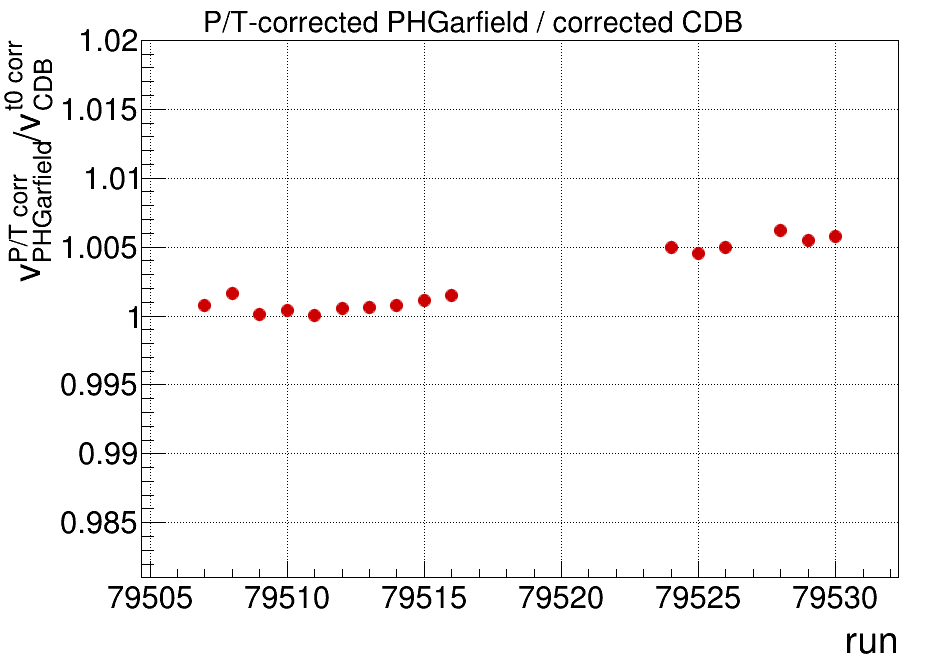

In [19]:
# P/T-corrected PHGarfield / corrected CDB ratio
YLIM = (0.981, 1.02)            # example: (0.98, 1.02)
XLIM = None
SAVE = True

g = get_obj(fT, "g_ratio_corr_combined", "g_new_ratio")
style_graph(g, root.kRed+1, 20)

c = make_canvas("c_new_ratio")
draw_one(g, "P/T-corrected PHGarfield / corrected CDB;run;v_{PHGarfield}^{P/T corr}/v_{CDB}^{t0 corr}", YLIM, XLIM)
c.SetLeftMargin(0.15)
g.GetYaxis().SetTitleOffset(1.25)
c.Draw()
save_canvas(c, "15_new_ratio_corrected", SAVE)

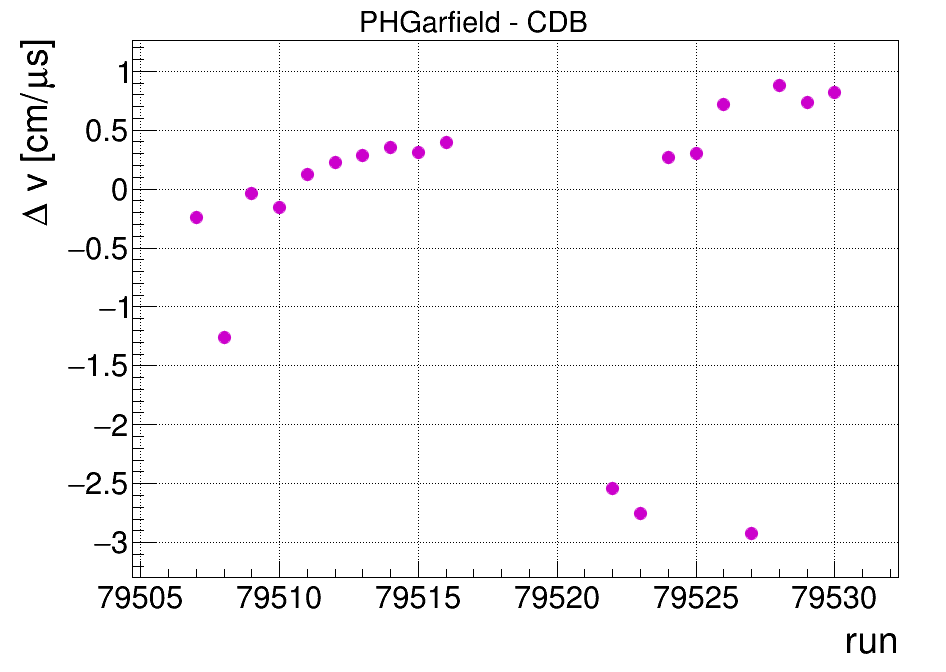

In [20]:
# P/T-corrected PHGarfield - CDB difference
YLIM = None            # example: (-0.15, 0.15)
XLIM = None
SAVE = False

g = get_obj(fT, "g_diff_combined", "g_new_diff")
style_graph(g, root.kMagenta+1, 20)

c = make_canvas("c_new_diff")
draw_one(g, "PHGarfield - CDB;run;#Delta v [cm/#mus]", YLIM, XLIM)
c.Draw()
save_canvas(c, "16_new_difference", SAVE)

Saved 17_pure_vs_pt_corrected_phgarfield


Info in <TCanvas::Print>: pdf file dv_plots/17_pure_vs_pt_corrected_phgarfield.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/17_pure_vs_pt_corrected_phgarfield.png has been created


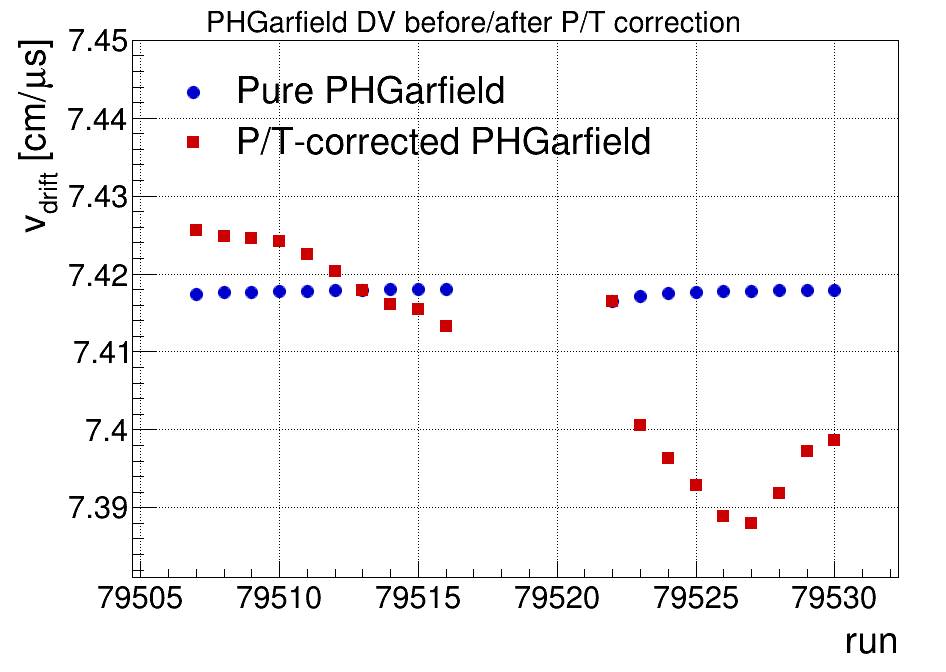

In [21]:
# Pure vs P/T-corrected PHGarfield
YLIM = (7.381, 7.45)            # example: (7.2, 7.8)
XLIM = None
SAVE = True

g1 = get_obj(fP, "g_mean_combined", "g_old_pure")
g2 = get_obj(fT, "g_mean_combined", "g_new_pt")

c = make_canvas("c_old_vs_new")
leg = draw_overlay(
    [(g1, "Pure PHGarfield", root.kBlue+1, 20),
     (g2, "P/T-corrected PHGarfield", root.kRed+1, 21)],
    "PHGarfield DV before/after P/T correction;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "17_pure_vs_pt_corrected_phgarfield", SAVE)

## Longer run list

Saved 18_long_sample_overlay


Info in <TCanvas::Print>: pdf file dv_plots/18_long_sample_overlay.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/18_long_sample_overlay.png has been created


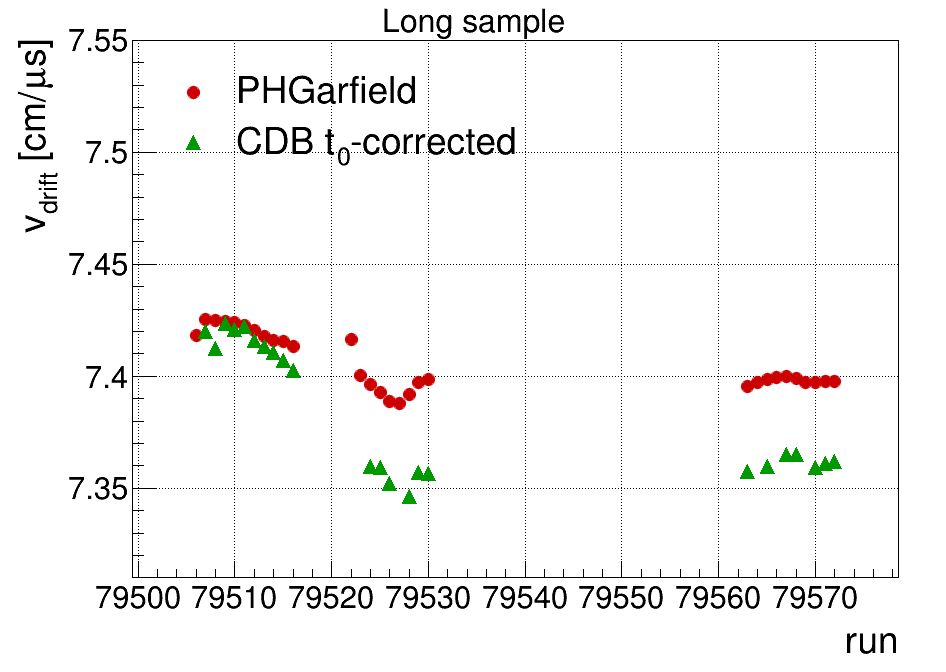

In [22]:
# Long sample: PHGarfield vs corrected CDB
YLIM = (7.31, 7.55)            # example: (7.2, 7.8)
XLIM = None
SAVE = True

g1 = get_obj(fL, "g_mean_combined", "g_long_dv")
g2 = get_obj(fL, "g_cdb_t0corr", "g_long_cdbcorr")

c = make_canvas("c_long_overlay")
leg = draw_overlay(
    [(g1, "PHGarfield", root.kRed+1, 20),
     (g2, "CDB t_{0}-corrected", root.kGreen+2, 22)],
    "Long sample;run;v_{drift} [cm/#mus]",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "18_long_sample_overlay", SAVE)

Saved 19_long_sample_ratio


Info in <TCanvas::Print>: pdf file dv_plots/19_long_sample_ratio.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/19_long_sample_ratio.png has been created


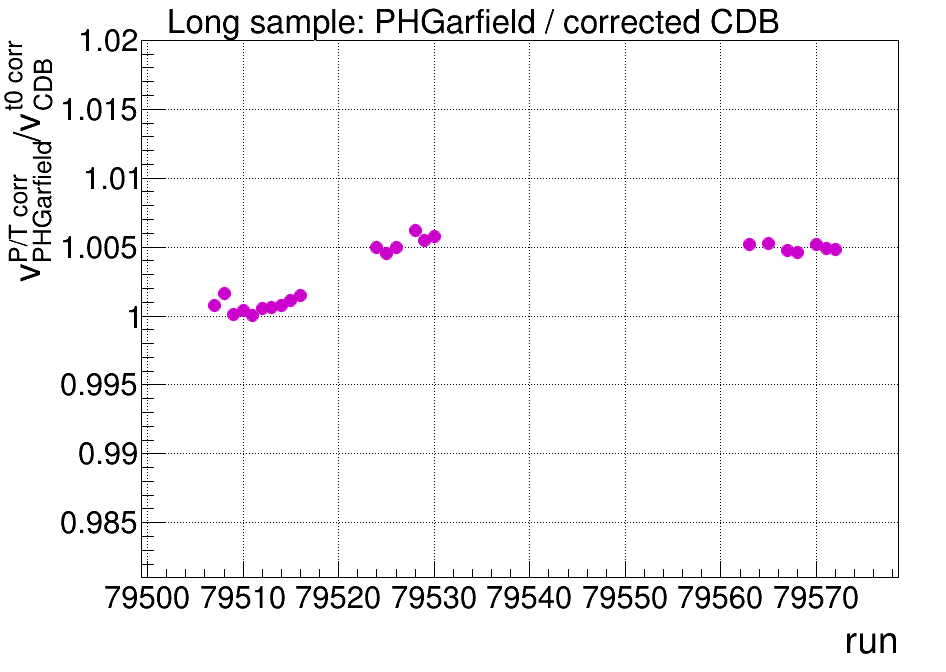

In [23]:
# Long sample ratio
YLIM = (0.981, 1.02)            # example: (0.98, 1.02)
XLIM = None
SAVE = True

g = get_obj(fL, "g_ratio_corr_combined", "g_long_ratio")
style_graph(g, root.kMagenta+1, 20)

c = make_canvas("c_long_ratio")
draw_one(g, "Long sample: PHGarfield / corrected CDB;run;v_{PHGarfield}^{P/T corr}/v_{CDB}^{t0 corr}", YLIM, XLIM)
c.SetLeftMargin(0.15)
g.GetYaxis().SetTitleOffset(1.25)
c.Draw()
save_canvas(c, "19_long_sample_ratio", SAVE)

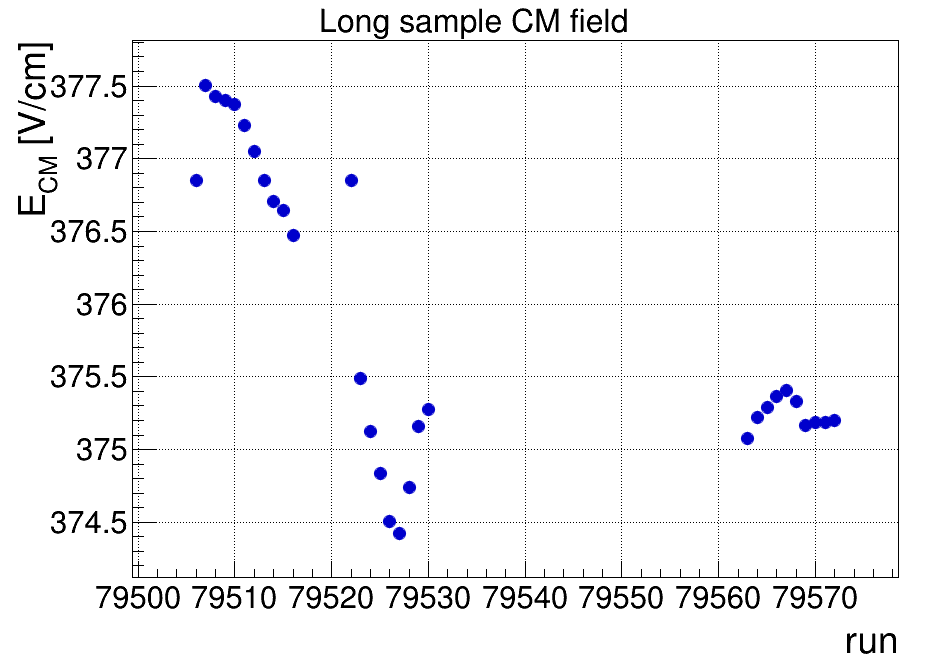

In [24]:
# Long sample CM field
YLIM = None
XLIM = None
SAVE = False

g = get_obj(fL, "g_cmfield", "g_long_cmfield")
style_graph(g, root.kBlue+1, 20)

c = make_canvas("c_long_cmfield")
draw_one(g, "Long sample CM field;run;E_{CM} [V/cm]", YLIM, XLIM)
c.Draw()
save_canvas(c, "20_long_sample_cmfield", SAVE)

## Backup spatial-dependence plots

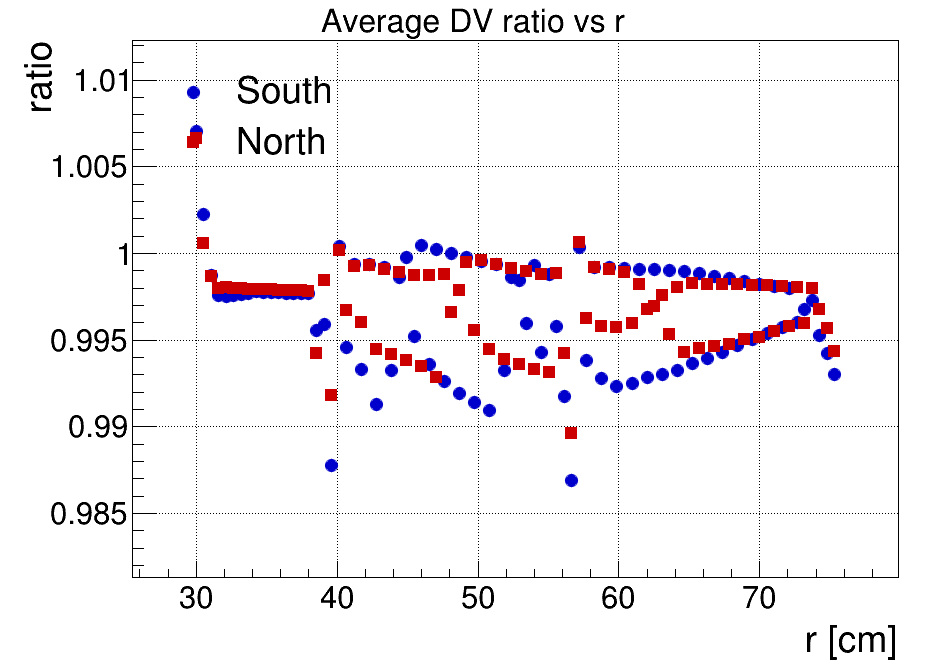

In [25]:
# Average DV ratio vs r
YLIM = None            # example: (0.98, 1.02)
XLIM = None
SAVE = False

g1 = get_obj(fT, "g_avg_ratio_r_south", "g_ratio_r_south")
g2 = get_obj(fT, "g_avg_ratio_r_north", "g_ratio_r_north")

c = make_canvas("c_ratio_vs_r")
leg = draw_overlay(
    [(g1, "South", root.kBlue+1, 20),
     (g2, "North", root.kRed+1, 21)],
    "Average DV ratio vs r;r [cm];ratio",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "21_average_dv_ratio_vs_r", SAVE)

Saved 22_average_dv_ratio_vs_z


Info in <TCanvas::Print>: pdf file dv_plots/22_average_dv_ratio_vs_z.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/22_average_dv_ratio_vs_z.png has been created


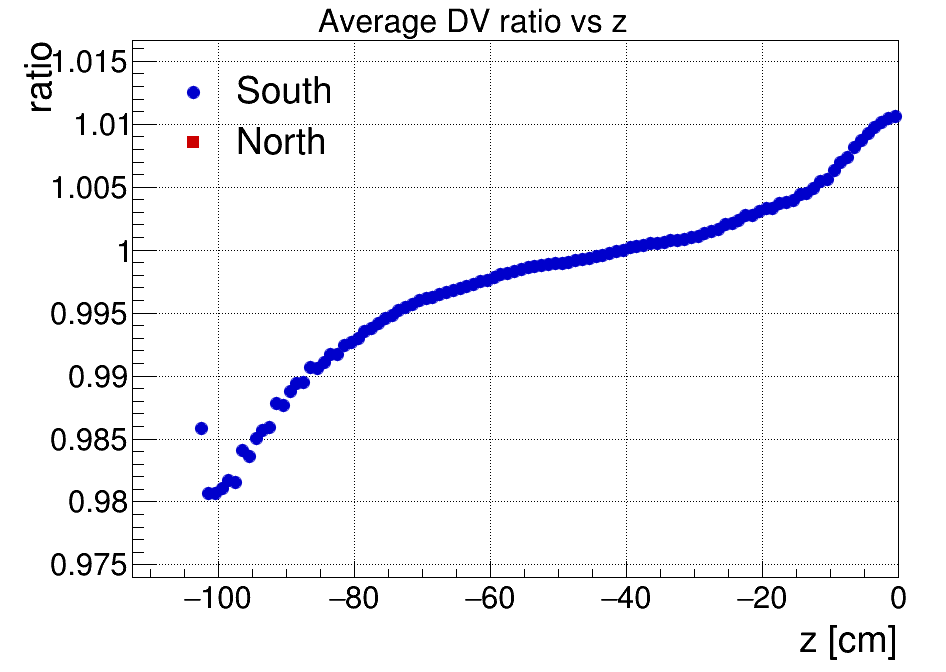

In [26]:
# Average DV ratio vs z
YLIM = None            # example: (0.98, 1.02)
XLIM = None
SAVE = True

g1 = get_obj(fT, "g_avg_ratio_z_south", "g_ratio_z_south")
g2 = get_obj(fT, "g_avg_ratio_z_north", "g_ratio_z_north")

c = make_canvas("c_ratio_vs_z")
leg = draw_overlay(
    [(g1, "South", root.kBlue+1, 20),
     (g2, "North", root.kRed+1, 21)],
    "Average DV ratio vs z;z [cm];ratio",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "22_average_dv_ratio_vs_z", SAVE)

Saved 23_trajectory_averaged_dv_ratio_vs_r


Info in <TCanvas::Print>: pdf file dv_plots/23_trajectory_averaged_dv_ratio_vs_r.pdf has been created
Info in <TCanvas::Print>: png file dv_plots/23_trajectory_averaged_dv_ratio_vs_r.png has been created


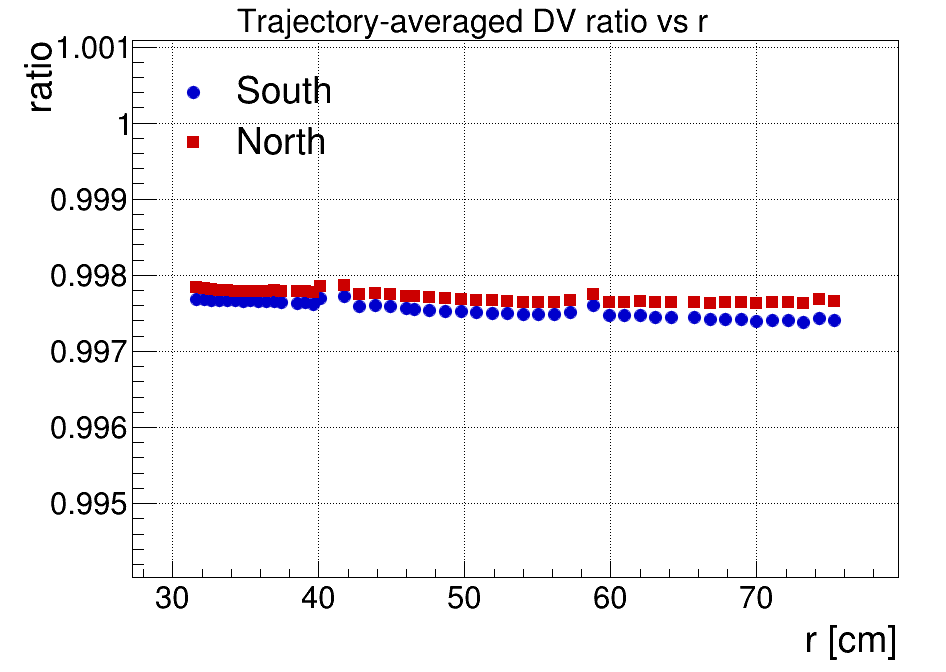

In [27]:
# Trajectory-averaged DV ratio vs r
YLIM = None            # example: (0.98, 1.02)
XLIM = None
SAVE = True

g1 = get_obj(fT, "g_avg_traj_ratio_r_south", "g_traj_ratio_r_south")
g2 = get_obj(fT, "g_avg_traj_ratio_r_north", "g_traj_ratio_r_north")

c = make_canvas("c_traj_ratio_vs_r")
leg = draw_overlay(
    [(g1, "South", root.kBlue+1, 20),
     (g2, "North", root.kRed+1, 21)],
    "Trajectory-averaged DV ratio vs r;r [cm];ratio",
    YLIM, XLIM
)
c.Draw()
save_canvas(c, "23_trajectory_averaged_dv_ratio_vs_r", SAVE)

### Notes

- This version uses **one plot per canvas**.
- To tune a plot, only edit the `YLIM` and `XLIM` values at the top of that plot’s cell.
- To save a plot, set `SAVE = True` in that cell.